### For making comparison plots


In [1]:
import subprocess, sys, os, importlib, re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import rf_functions 
importlib.reload(rf_functions)

from scipy.stats import randint

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, classification_report

In [2]:
def overall_rf(results_dir, transformed_data_dir, dataset):
    # Initialize an empty list to store the results
    results = []
    
    files = [f for f in os.listdir(transformed_data_dir) if f.startswith('transformed')]

    for filename in files:
        x_train, x_test, y_train, y_test, y_pred = rf_functions.perform_random_forest(transformed_data_dir, filename)

        # Perform Random Forest and get mse and r2
        mae, mse, rmse, r2, adjusted_r2 = rf_functions.obtain_rf_evaluations(x_train, y_test, y_pred)

        # Extract the energy range and cumulative variance ratio from the filename
        energy_range_match = re.search(r'\[([-+]?\d*\.\d+|\d+),([-+]?\d*\.\d+|\d+)\]', filename)
        cum_variance_match = re.search(r'var([\d\.]+)', filename)

        if energy_range_match and cum_variance_match:
            energy_range = f"{energy_range_match.group(1)},{energy_range_match.group(2)}"
            cum_variance = cum_variance_match.group(1).rstrip('.')

            # Append the results to the list as a dictionary
            results.append({
                'dataset': dataset.replace('transformed_data_', ''),
                'energy_range': energy_range,
                'cum_variance': cum_variance,
                'MAE': mae,
                'MSE': mse,
                'RMSE': rmse,
                'R^2': r2,
                'Adjusted_R^2': adjusted_r2
            })

    # Convert the results list into a DataFrame
    results_df = pd.DataFrame(results)

    # Save results in overall results excel
    excel_name = os.path.join(results_dir, 'overall_results.xlsx')
    sheet_name = f'rf_results_{dataset}'

    # Save to Excel (append if file already exists)
    if os.path.exists(excel_name):
        # If Excel file does not exists, create a new Excel file
        with pd.ExcelWriter(excel_name, mode="a", engine="openpyxl", if_sheet_exists="replace") as writer:
            results_df.to_excel(writer, sheet_name=sheet_name, index=False) 
    else:
        with pd.ExcelWriter(excel_name) as writer:
            results_df.to_excel(writer, sheet_name=sheet_name, index=False) 

    return results_df

In [4]:
base_dir = os.path.dirname(os.getcwd())
results_dir = os.path.join(base_dir, 'RESULTS')

transformed_data_dir = os.path.join(results_dir,'transformed_data_DOSCAR_files')

cur_results_set_5 = overall_rf(results_dir, transformed_data_dir, 'DOSCAR_files')
cur_results_set_5

c:\Users\jespe\Desktop\[THESIS] Code\-ESPEJO-THESIS-DOS-ML-Model-\.venv\Lib\site-packages\openpyxl\workbook\child.py:99: UserWarning: Title is more than 31 characters. Some applications may not be able to read the file
  warnings.warn("Title is more than 31 characters. Some applications may not be able to read the file")


,dataset,energy_range,cum_variance,MAE,MSE,RMSE,R^2,Adjusted_R^2
0,DOSCAR_files,"-1.46,3.27",0.80,0.178832,0.054292,0.233005,-0.310061,-0.358582
1,DOSCAR_files,"-1.46,3.27",0.90,0.134002,0.031586,0.177725,0.237822,0.163098
2,DOSCAR_files,"-10.00,10.00",0.80,0.127725,0.031538,0.177589,0.238990,-0.151800
3,DOSCAR_files,"-10.00,10.00",0.90,0.130654,0.031017,0.176118,0.251545,-1.095674
4,DOSCAR_files,"-5.00,5.00",0.80,0.147765,0.039606,0.199014,0.044291,-0.244644
5,DOSCAR_files,"-5.00,5.00",0.90,0.152560,0.038201,0.195451,0.078204,-0.564260


In [ ]:
def plot_rf_comparison(y_test_bl, y_pred_bl, y_test_tuned, y_pred_tuned, energy_range, variance):
    # Extract sample indices from the first column of y_test (if it's a DataFrame)
    y_actual_bl = y_test_bl.values
    y_actual_tuned = y_test_tuned.values

    # Calculate axis limits for equal scaling
    min_val = min(y_actual_bl.min(), y_pred_bl.min(), y_actual_tuned.min(), y_pred_tuned.min()) - 0.2
    max_val = max(y_actual_bl.max(), y_pred_bl.max(), y_actual_tuned.max(), y_pred_tuned.max()) + 0.2

    # Plot actual vs predicted with y=x line
    plt.figure(figsize=(8, 8))
    plt.plot(y_actual_bl, y_pred_bl, 'o', markersize=6, label='Baseline Model Predictions')
    plt.plot(y_actual_tuned, y_pred_tuned, 'go', markersize=6, label='Tuned Model Predictions')
    plt.plot([min_val, max_val], [min_val, max_val], 'r-', label='$y = x$', linewidth=2)  # y=x line

    plt.xlabel('Actual Adsorption Energy')
    plt.ylabel('Predicted Adsorption Energy')
    plt.title(f'Actual vs Predicted Adsorption Energy for {energy_range} and {variance * 100}% variance')
    plt.legend()
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.grid(True)
    plt.show()

In [10]:
def plot_rf(transformed_data_dir, energy_range, variance):
    filename = f'transformed_data_{energy_range}_var{variance:.2f}.txt'

    x_train, x_test, y_train, y_test, y_pred = rf_functions.perform_random_forest(transformed_data_dir, filename)
    rf_functions.plot_rf_results(y_test, y_pred, energy_range, variance)

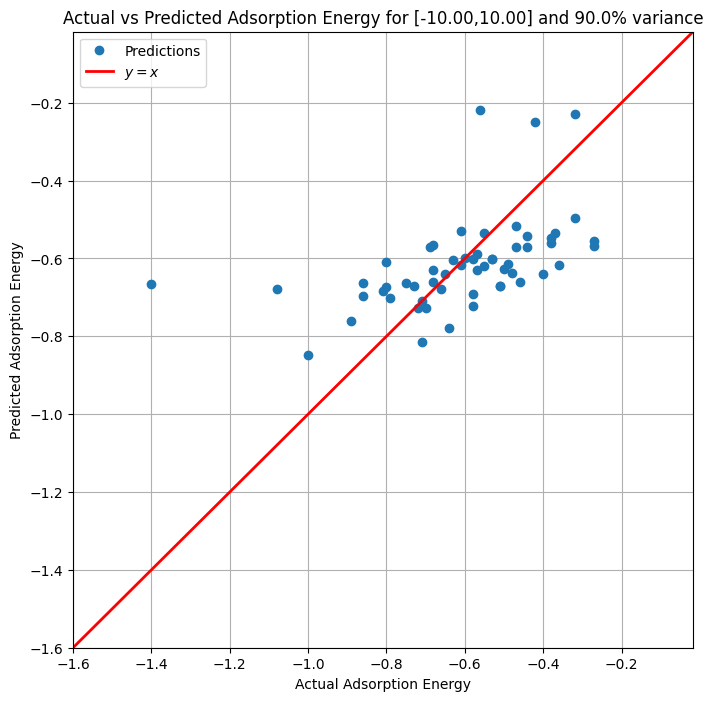

In [11]:
### FOR -10.00, 10.00 AND 90% VARIANCE

energy_range = '[-10.00,10.00]'
variance = 0.90

filename = f'transformed_data_{energy_range}_var{variance:.2f}.txt'

x_train, x_test, y_train, y_test_bl, y_pred_bl = rf_functions.perform_random_forest(transformed_data_dir, filename)

rf_functions.plot_rf_results(y_test_bl, y_pred_bl, energy_range, variance)

In [8]:
def perform_gridsearch(transformed_data_dir, filename, param_grid):
    filepath = os.path.join(transformed_data_dir, filename)

    # Load and process the data
    pca_data = rf_functions.load_pca_transformed_data(filepath)
    merged_data = rf_functions.adsorption_energy_for_dataset(pca_data)

    # Prepare the data
    x = merged_data.drop(columns=['Molecule','Ads.'])
    y = merged_data['Ads.']

    # Split the data
    x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2, random_state=42)


    # Perform Grid Search with 5-fold Cross-Validation
    grid_search = GridSearchCV(
        estimator = RandomForestRegressor(random_state=42),
        param_grid = param_grid,
        cv = 5,  # 5-fold cross-validation
        scoring = 'neg_mean_squared_error',  # Minimize MSE
        n_jobs = -1,  # Use all CPU cores
        verbose = 2
    )

    # Fit the model
    grid_search.fit(x_train, y_train)

    # Evaluate on test set
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(x_test)

    return grid_search, x_train, x_test, y_train, y_test, y_pred

In [12]:
# Define hyperparameter distribution
param_grid = {
    'n_estimators': [50, 100, 200, 500, 1000],  # Number of trees
    'max_depth': [None, 3, 5, 10, 20],          # Maximum depth of trees
    'min_samples_split': [2, 5, 10],            # Minimum samples per split
    'min_samples_leaf': [1, 2, 4, 10],          # Minimum samples per leaf
    'max_features': ['sqrt', 'log2', None, 10], # Number of features per tree
    'bootstrap': [True, False]                  # Whether to use bootstrapping
}

In [13]:
### FOR -10.00, 10.00 AND 90% VARIANCE

transformed_data_dir = os.path.join(results_dir,'transformed_data_DOSCAR_files')

energy_range = '[-10.00,10.00]'
variance = 0.90

filename = f'transformed_data_{energy_range}_var{variance:.2f}.txt'

grid_search, x_train, x_test, y_train, y_test_tuned, y_pred_tuned = perform_gridsearch(transformed_data_dir, filename, param_grid)

# Best Parameters
best_params = grid_search.best_params_

# Convert the dictionary of best parameters to a DataFrame and transpose it
best_params_df = pd.DataFrame(list(best_params.items()), columns=['Parameter', 'Value'])

print(f"Best Parameters (Grid Search): ")
best_params_df

Fitting 5 folds for each of 2400 candidates, totalling 12000 fits
Best Parameters (Grid Search): 


,Parameter,Value
0,bootstrap,False
1,max_depth,None
2,max_features,sqrt
3,min_samples_leaf,2
4,min_samples_split,2
5,n_estimators,50


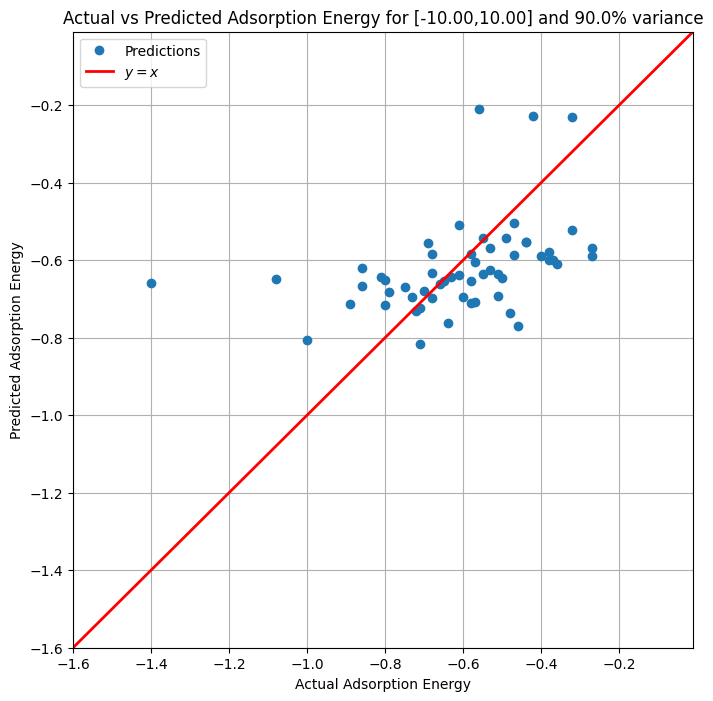

In [14]:
rf_functions.plot_rf_results(y_test_tuned, y_pred_tuned, energy_range, variance)

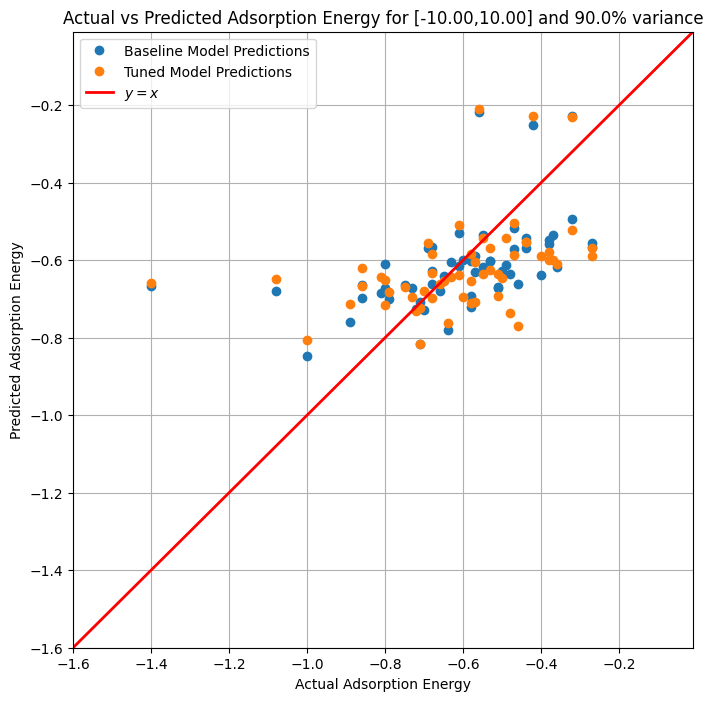

In [15]:
plot_rf_comparison(y_test_bl, y_pred_bl, y_test_tuned, y_pred_tuned, energy_range, variance)